## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
import lime
import lime.lime_tabular

## Load model and data

In [ ]:
with open('models/random-forest-trained.pkl', 'rb') as file:
    rf_model = pickle.load(file)

In [3]:
data = pd.read_csv("data/cleaned_static_features.csv",index_col=0)
with open("data/groups.pkl", 'rb') as file:
    groups = pickle.load(file)
disorders = ["Voice Disorders", "Neurological and Neurodegenerative Disorders", "Mood and Psychiatric Disorders","Respiratory Disorders"]
y_voice = data["Voice Disorders"].copy().to_numpy()
X = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders).to_numpy()

In [4]:
feature_names = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders).columns

## Train and test

In [5]:
def train_test_split_groups(y, groups, total_n_groups:int, split_size:float=0.15):
    n_test_groups = int(total_n_groups*0.15)
    group_ones = groups[np.where(y==1)[0]]
    group_zeros = groups[np.where(y==0)[0]]
    test_groups_one = np.random.choice(group_ones, int(n_test_groups/2), replace=False)
    test_groups_zero = np.random.choice(group_zeros, int(n_test_groups/2), replace=False)
    test_groups = np.concatenate((test_groups_one, test_groups_zero))
    train_groups = np.array([g for g in groups if g not in test_groups])
    train_inds = np.array([i for i in range(len(y)) if groups[i] in train_groups])
    test_inds = np.array([i for i in range(len(y)) if groups[i] in test_groups])
    return train_inds, test_inds

In [ ]:
train_idx, test_idx = train_test_split_groups(y_voice, groups, total_n_groups=440)
X_train, y_train = X[train_idx], y_voice[train_idx]
X_test, y_test = X[test_idx], y_voice[test_idx]

gkf = GroupKFold(n_splits=7,shuffle=False)
fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/test split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    # Fit on training groups
    rf_model.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = rf_model.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = rf_model.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(val_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[val_idx]).tolist()
    })

# Convert to DataFrame for easier plotting/analysis
decision_tree_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
decision_tree_gkf_fold_results.head(10)

Per-fold GKF results (first 10 rows):


,fold,train_idx_count,val_idx_count,train_f1,val_f1,val_groups
0,0,14083,2346,0.661370,0.562863,"[1, 18, 27, 30, 31, 44, 45, 49, 50, 51, 56, 58..."
1,1,14100,2329,0.654211,0.614628,"[2, 13, 17, 21, 43, 44, 52, 55, 56, 68, 71, 72..."
2,2,14071,2358,0.671731,0.539828,"[3, 9, 12, 38, 39, 40, 48, 49, 53, 54, 55, 65,..."
3,3,14072,2357,0.642023,0.673666,"[0, 7, 11, 15, 20, 22, 26, 32, 35, 36, 40, 41,..."
4,4,14093,2336,0.657228,0.625572,"[14, 16, 19, 28, 33, 34, 51, 52, 61, 62, 63, 6..."
5,5,14074,2355,0.659582,0.653610,"[4, 5, 37, 46, 47, 59, 60, 68, 69, 70, 74, 75,..."
6,6,14081,2348,0.663932,0.635753,"[6, 8, 10, 23, 24, 25, 29, 37, 38, 42, 44, 45,..."


In [ ]:
# final eval
y_test_preds = rf_model.predict(X_test)
test_f1 = f1_score(y_test, y_test_preds, average="weighted")
print(f"Test F1 (weighted): {np.round(test_f1,2)}")

Test F1 (weighted): 0.69


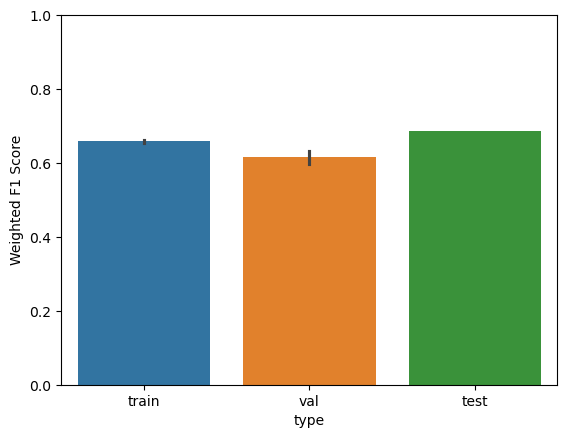

In [8]:
train_f1 = decision_tree_gkf_fold_results["train_f1"].mean()
val_f1 = decision_tree_gkf_fold_results["val_f1"].mean()

results_dict = {"f1":[], "type":[]}
for idx,row in decision_tree_gkf_fold_results.iterrows():
    results_dict["f1"].append(row.train_f1)
    results_dict["type"].append("train")
    results_dict["f1"].append(row.val_f1)
    results_dict["type"].append("val")
results_dict["f1"].append(test_f1)
results_dict["type"].append("test")

results_df = pd.DataFrame.from_dict(results_dict)

plt.figure()
sns.barplot(data=results_df, x="type", y="f1", palette="tab10", hue="type", errorbar="se")
plt.ylabel("Weighted F1 Score")
plt.ylim([0, 1.0])
plt.show()

## Explainability

#### LIME -- Local Interpretable Model Explainer
- Generate random perturbations to input features
- Predict class probabilities using perturbed signal
- Compute similarity between perturbed features and original features
- Fit interpretable model (e.g. linear regression) to perturbed signal and class probabilities, with similarity scores as weights
- Interpretable model feature weights represent feature importances for the original class prediction

In [58]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train, 
    mode="classification",
    class_names=[0,1],
    feature_names=feature_names, 
    discretize_continuous=True
)

In [ ]:
rand_1_ind = np.random.choice(np.where(y_test==1)[0])
exp = explainer.explain_instance(
    X_test[rand_1_ind], 
    rf_model.predict_proba, 
    labels=[0,1],
    num_features=10
)

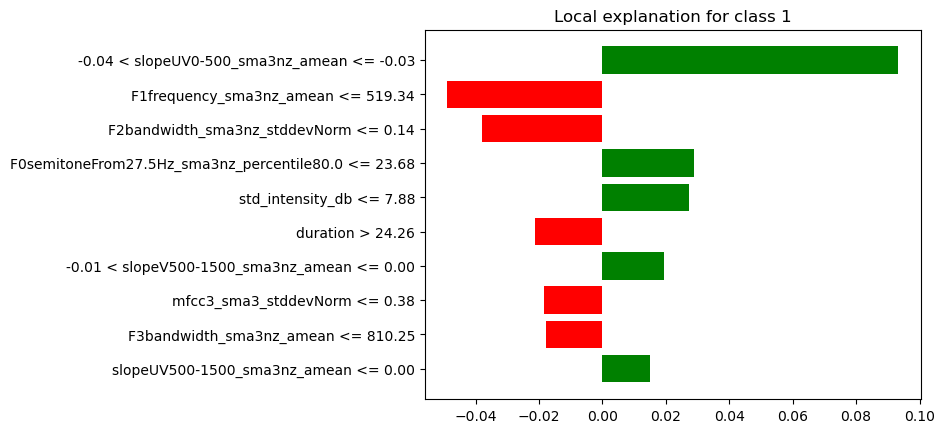

In [60]:
fig = exp.as_pyplot_figure()

#### SHAP